# Probability of DM having enough KE to enter copper

Probability model: normal_component

Epsilon contour locations:

epsilon for P(E_perp > U) = 1e-01: 0.0109649878601
epsilon for P(E_perp > U) = 1e-02: 0.0268898141604
epsilon for P(E_perp > U) = 1e-03: 0.0438818054969
epsilon for P(E_perp > U) = 1e-04: 0.0613458227038
epsilon for P(E_perp > U) = 1e-05: 0.079075608151
epsilon for P(E_perp > U) = 1e-06: 0.0969755711817
epsilon for P(E_perp > U) = 1e-10: 0.169493400906

Corresponding normal-energy thresholds:

U at P = 1e-01: 5.603108796530e-21 J
U at P = 1e-02: 1.374069503596e-20 J
U at P = 1e-03: 2.242360260894e-20 J
U at P = 1e-04: 3.134771540165e-20 J
U at P = 1e-05: 4.040763576515e-20 J
U at P = 1e-06: 4.955451687387e-20 J
U at P = 1e-10: 8.661112786283e-20 J

Saved heat map to: mcp_normal_energy_probability_heatmap.png


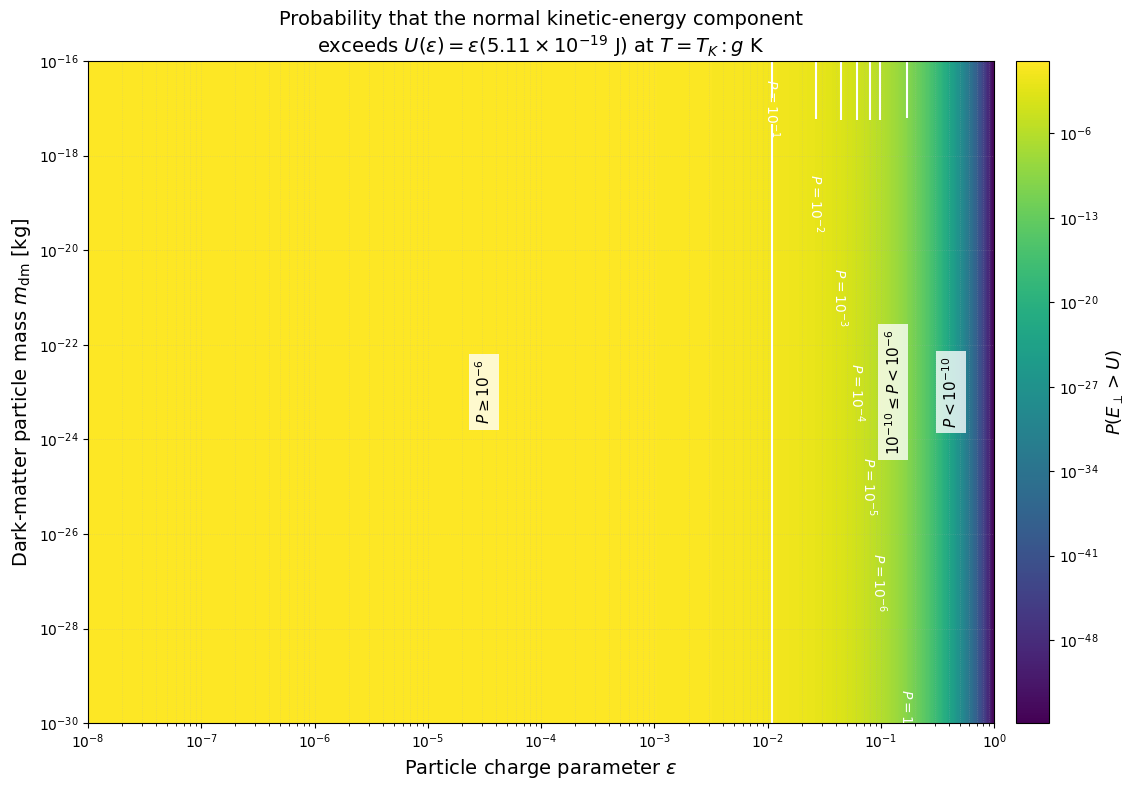

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from scipy.optimize import brentq
from scipy.special import erfc


# ============================================================
# Physical constants and simulation settings
# ============================================================

K_B = 1.380649e-23       # Boltzmann constant [J/K]
T_K = 300.0              # Temperature [K]

# Energy threshold:
#
#     U(epsilon) = epsilon * U0
#
# This assumes that 5.11e-19 is an energy in joules.
U0_J = 5.11e-19          # [J]


# ============================================================
# Choose the probability model
# ============================================================

# "normal_component":
#
#     Probability that a randomly sampled thermal particle has
#     normal kinetic-energy magnitude
#
#         E_perp = (1/2) m v_perp^2
#
#     greater than U.
#
#     P(E_perp > U) = erfc(sqrt(U / (k_B T)))
#
#
# "incident_flux":
#
#     Fraction of particles actually striking the surface whose
#     normal kinetic energy exceeds U. This includes the v_perp
#     weighting associated with flux onto a surface.
#
#     P_flux(E_perp > U) = exp(-U / (k_B T))
#
PROBABILITY_MODEL = "normal_component"

VALID_PROBABILITY_MODELS = {
    "normal_component",
    "incident_flux",
}

if PROBABILITY_MODEL not in VALID_PROBABILITY_MODELS:
    raise ValueError(
        f"PROBABILITY_MODEL must be one of "
        f"{sorted(VALID_PROBABILITY_MODELS)}."
    )


# ============================================================
# Parameter ranges
# ============================================================

M_DM_MIN_KG = 1.0e-30
M_DM_MAX_KG = 1.0e-16

EPS_MIN = 1.0e-8
EPS_MAX = 1.0

N_MASS = 500
N_EPS = 700


# Probability levels to print and plot.
PRINT_PROBABILITY_LEVELS = [
    1.0e-1,
    1.0e-2,
    1.0e-3,
    1.0e-4,
    1.0e-5,
    1.0e-6,
    1.0e-10,
]

# Matplotlib requires contour levels in increasing order.
PROBABILITY_CONTOURS = sorted(
    PRINT_PROBABILITY_LEVELS
)


# ============================================================
# Normal-energy probability
# ============================================================

def normal_energy_tail_probability(
    threshold_energy_J,
    temperature_K,
    probability_model=PROBABILITY_MODEL,
):
    """
    Return the probability that the kinetic-energy component
    normal to a surface exceeds threshold_energy_J.

    Parameters
    ----------
    threshold_energy_J : float or ndarray
        Normal-energy threshold U in joules.

    temperature_K : float
        Temperature in kelvin.

    probability_model : str
        Either:

        "normal_component"
            Probability for a randomly sampled particle:

                P((1/2) m v_perp^2 > U)
                    = erfc(sqrt(U / (k_B T))).

        "incident_flux"
            Fraction of particles impacting the surface whose
            normal energy exceeds U:

                P_flux((1/2) m v_perp^2 > U)
                    = exp(-U / (k_B T)).

    Returns
    -------
    float or ndarray
        Requested tail probability.
    """
    threshold_energy_J = np.asarray(
        threshold_energy_J,
        dtype=float,
    )

    if temperature_K <= 0.0:
        raise ValueError(
            "temperature_K must be positive."
        )

    if np.any(threshold_energy_J < 0.0):
        raise ValueError(
            "threshold_energy_J must be nonnegative."
        )

    if probability_model not in VALID_PROBABILITY_MODELS:
        raise ValueError(
            f"probability_model must be one of "
            f"{sorted(VALID_PROBABILITY_MODELS)}."
        )

    x = threshold_energy_J / (
        K_B * temperature_K
    )

    if probability_model == "normal_component":
        probability = erfc(
            np.sqrt(x)
        )

    elif probability_model == "incident_flux":
        probability = np.exp(
            -x
        )

    return np.clip(
        probability,
        0.0,
        1.0,
    )


def probability_for_epsilon(epsilon):
    """
    Return the selected normal-energy probability for

        U = epsilon * U0.
    """
    threshold_energy_J = epsilon * U0_J

    return normal_energy_tail_probability(
        threshold_energy_J=threshold_energy_J,
        temperature_K=T_K,
        probability_model=PROBABILITY_MODEL,
    )


def find_epsilon_for_probability(
    target_probability,
):
    """
    Find epsilon such that the selected probability equals
    target_probability.
    """
    if not (
        0.0 < target_probability < 1.0
    ):
        raise ValueError(
            "target_probability must lie between 0 and 1."
        )

    probability_at_min = probability_for_epsilon(
        EPS_MIN
    )

    probability_at_max = probability_for_epsilon(
        EPS_MAX
    )

    if not (
        probability_at_min
        >= target_probability
        >= probability_at_max
    ):
        return np.nan

    epsilon_solution = brentq(
        lambda epsilon: (
            probability_for_epsilon(epsilon)
            - target_probability
        ),
        EPS_MIN,
        EPS_MAX,
        xtol=1.0e-14,
        rtol=1.0e-12,
    )

    return epsilon_solution


# ============================================================
# Calculate contour locations
# ============================================================

contour_results = []

for target_probability in PRINT_PROBABILITY_LEVELS:
    epsilon_level = find_epsilon_for_probability(
        target_probability
    )

    if np.isfinite(epsilon_level):
        threshold_energy_J = (
            epsilon_level * U0_J
        )
    else:
        threshold_energy_J = np.nan

    contour_results.append(
        {
            "probability": target_probability,
            "epsilon": epsilon_level,
            "energy_J": threshold_energy_J,
        }
    )


# ============================================================
# Print contour locations
# ============================================================

print(
    f"Probability model: {PROBABILITY_MODEL}"
)

print(
    "\nEpsilon contour locations:\n"
)

for result in contour_results:
    probability = result["probability"]
    epsilon_level = result["epsilon"]

    if np.isfinite(epsilon_level):
        print(
            f"epsilon for P(E_perp > U) = "
            f"{probability:.0e}: "
            f"{epsilon_level:.12g}"
        )
    else:
        print(
            f"epsilon for P(E_perp > U) = "
            f"{probability:.0e}: "
            "outside the selected epsilon range"
        )


print(
    "\nCorresponding normal-energy thresholds:\n"
)

for result in contour_results:
    probability = result["probability"]
    threshold_energy_J = result["energy_J"]

    if np.isfinite(threshold_energy_J):
        print(
            f"U at P = {probability:.0e}: "
            f"{threshold_energy_J:.12e} J"
        )
    else:
        print(
            f"U at P = {probability:.0e}: "
            "outside the selected epsilon range"
        )


epsilon_by_probability = {
    result["probability"]: result["epsilon"]
    for result in contour_results
}


# ============================================================
# Construct the (m_dm, epsilon) grid
# ============================================================

m_dm_arr = np.logspace(
    np.log10(M_DM_MIN_KG),
    np.log10(M_DM_MAX_KG),
    N_MASS,
)

epsilon_arr = np.logspace(
    np.log10(EPS_MIN),
    np.log10(EPS_MAX),
    N_EPS,
)

epsilon_grid, m_dm_grid = np.meshgrid(
    epsilon_arr,
    m_dm_arr,
)

threshold_energy_grid_J = (
    epsilon_grid * U0_J
)

probability_grid = normal_energy_tail_probability(
    threshold_energy_J=threshold_energy_grid_J,
    temperature_K=T_K,
    probability_model=PROBABILITY_MODEL,
)

# Avoid exact zeros with logarithmic color normalization.
plot_probability_grid = np.maximum(
    probability_grid,
    np.finfo(float).tiny,
)


# ============================================================
# Plot the heat map
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 8),
)

heatmap = ax.pcolormesh(
    epsilon_grid,
    m_dm_grid,
    plot_probability_grid,
    shading="auto",
    norm=LogNorm(
        vmin=max(
            np.min(plot_probability_grid),
            1.0e-60,
        ),
        vmax=1.0,
    ),
    cmap="viridis",
)

colorbar = fig.colorbar(
    heatmap,
    ax=ax,
    pad=0.02,
)

if PROBABILITY_MODEL == "normal_component":
    colorbar_label = (
        r"$P(E_{\perp}>U)$"
    )
else:
    colorbar_label = (
        r"$P_{\mathrm{impact}}(E_{\perp}>U)$"
    )

colorbar.set_label(
    colorbar_label,
    fontsize=13,
)


# ============================================================
# Draw contour lines
# ============================================================

contours = ax.contour(
    epsilon_grid,
    m_dm_grid,
    probability_grid,
    levels=PROBABILITY_CONTOURS,
    colors="white",
    linewidths=1.5,
)

contour_label_format = {
    1.0e-10: r"$P=10^{-10}$",
    1.0e-6: r"$P=10^{-6}$",
    1.0e-5: r"$P=10^{-5}$",
    1.0e-4: r"$P=10^{-4}$",
    1.0e-3: r"$P=10^{-3}$",
    1.0e-2: r"$P=10^{-2}$",
    1.0e-1: r"$P=10^{-1}$",
}


# ============================================================
# Stagger contour-label positions
# ============================================================

label_mass_positions = np.logspace(
    np.log10(M_DM_MIN_KG) + 1.0,
    np.log10(M_DM_MAX_KG) - 1.0,
    len(PROBABILITY_CONTOURS),
)

manual_label_positions = []

for probability_level, label_mass in zip(
    PROBABILITY_CONTOURS,
    label_mass_positions,
):
    epsilon_level = epsilon_by_probability.get(
        probability_level,
        np.nan,
    )

    if np.isfinite(epsilon_level):
        manual_label_positions.append(
            (
                epsilon_level,
                label_mass,
            )
        )

ax.clabel(
    contours,
    inline=True,
    inline_spacing=5,
    fontsize=10,
    fmt=contour_label_format,
    manual=manual_label_positions,
)


# ============================================================
# Label requested probability regions
# ============================================================

epsilon_at_1e_minus_6 = (
    epsilon_by_probability[1.0e-6]
)

epsilon_at_1e_minus_10 = (
    epsilon_by_probability[1.0e-10]
)

region_label_mass = np.sqrt(
    M_DM_MIN_KG * M_DM_MAX_KG
)


# P >= 1e-6 region.
if np.isfinite(epsilon_at_1e_minus_6):
    label_epsilon = np.sqrt(
        EPS_MIN
        * epsilon_at_1e_minus_6
    )

    ax.text(
        label_epsilon,
        region_label_mass,
        r"$P\geq10^{-6}$",
        ha="center",
        va="center",
        fontsize=11,
        rotation=90,
        bbox={
            "facecolor": "white",
            "alpha": 0.78,
            "edgecolor": "none",
            "pad": 4,
        },
    )


# 1e-10 <= P < 1e-6 region.
if (
    np.isfinite(epsilon_at_1e_minus_6)
    and np.isfinite(epsilon_at_1e_minus_10)
):
    label_epsilon = np.sqrt(
        epsilon_at_1e_minus_6
        * epsilon_at_1e_minus_10
    )

    ax.text(
        label_epsilon,
        region_label_mass,
        r"$10^{-10}\leq P<10^{-6}$",
        ha="center",
        va="center",
        fontsize=11,
        rotation=90,
        bbox={
            "facecolor": "white",
            "alpha": 0.78,
            "edgecolor": "none",
            "pad": 4,
        },
    )


# P < 1e-10 region.
if np.isfinite(epsilon_at_1e_minus_10):
    label_epsilon = np.sqrt(
        epsilon_at_1e_minus_10
        * EPS_MAX
    )

    ax.text(
        label_epsilon,
        region_label_mass,
        r"$P<10^{-10}$",
        ha="center",
        va="center",
        fontsize=11,
        rotation=90,
        bbox={
            "facecolor": "white",
            "alpha": 0.78,
            "edgecolor": "none",
            "pad": 4,
        },
    )


# ============================================================
# Axis formatting
# ============================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    EPS_MIN,
    EPS_MAX,
)

ax.set_ylim(
    M_DM_MIN_KG,
    M_DM_MAX_KG,
)

ax.set_xlabel(
    r"Particle charge parameter $\epsilon$",
    fontsize=14,
)

ax.set_ylabel(
    r"Dark-matter particle mass "
    r"$m_{\mathrm{dm}}$ [kg]",
    fontsize=14,
)

if PROBABILITY_MODEL == "normal_component":
    title_description = (
        "Probability that the normal kinetic-energy component"
    )
else:
    title_description = (
        "Surface-impact flux fraction whose normal kinetic energy"
    )

ax.set_title(
    title_description
    + "\n"
    + r"exceeds "
    + r"$U(\epsilon)=\epsilon"
    + r"(5.11\times10^{-19}\ {\rm J})$ "
    + r"at $T={T_K:g}\ {\rm K}$",
    fontsize=14,
)

ax.grid(
    which="both",
    linestyle=":",
    linewidth=0.5,
    alpha=0.35,
)

fig.tight_layout()


# ============================================================
# Save and display
# ============================================================

output_filename = (
    "mcp_normal_energy_probability_heatmap.png"
)

plt.savefig(
    output_filename,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"\nSaved heat map to: {output_filename}"
)

plt.show()